In [ ]:
from google.colab import files
import zipfile
import os
import shutil

# Upload northstar_dataset.zip
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
extract_dir = "/content/northstar_dataset"

# Remove old extracted folder if it already exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

# Extract ZIP file
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

# Show extracted files
for root, dirs, files_list in os.walk(extract_dir):
    for file in files_list:
        print(os.path.join(root, file))

Saving northstar_dataset.zip to northstar_dataset.zip
/content/northstar_dataset/northstar_dataset/incidents.csv
/content/northstar_dataset/northstar_dataset/deliveries.csv
/content/northstar_dataset/northstar_dataset/customers.csv
/content/northstar_dataset/northstar_dataset/data_dictionary.csv
/content/northstar_dataset/northstar_dataset/app_events.csv
/content/northstar_dataset/northstar_dataset/orders.csv
/content/northstar_dataset/northstar_dataset/drivers.csv
/content/northstar_dataset/northstar_dataset/complaints.csv
/content/northstar_dataset/northstar_dataset/README.txt
/content/northstar_dataset/northstar_dataset/hubs.csv
/content/northstar_dataset/northstar_dataset/vehicles.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Find all CSV files inside the extracted dataset folder
csv_files = []

for root, dirs, files_list in os.walk("/content/northstar_dataset"):
    for file in files_list:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

csv_files

['/content/northstar_dataset/northstar_dataset/incidents.csv',
 '/content/northstar_dataset/northstar_dataset/deliveries.csv',
 '/content/northstar_dataset/northstar_dataset/customers.csv',
 '/content/northstar_dataset/northstar_dataset/data_dictionary.csv',
 '/content/northstar_dataset/northstar_dataset/app_events.csv',
 '/content/northstar_dataset/northstar_dataset/orders.csv',
 '/content/northstar_dataset/northstar_dataset/drivers.csv',
 '/content/northstar_dataset/northstar_dataset/complaints.csv',
 '/content/northstar_dataset/northstar_dataset/hubs.csv',
 '/content/northstar_dataset/northstar_dataset/vehicles.csv']

In [ ]:
# Helper function to load CSV file by name
def read_dataset(file_name):
    file_path = [f for f in csv_files if os.path.basename(f) == file_name][0]
    return pd.read_csv(file_path)

customers = read_dataset("customers.csv")
orders = read_dataset("orders.csv")
deliveries = read_dataset("deliveries.csv")
complaints = read_dataset("complaints.csv")
incidents = read_dataset("incidents.csv")
drivers = read_dataset("drivers.csv")
vehicles = read_dataset("vehicles.csv")
hubs = read_dataset("hubs.csv")
app_events = read_dataset("app_events.csv")

print("All datasets loaded successfully")
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Complaints:", complaints.shape)
print("Incidents:", incidents.shape)
print("Drivers:", drivers.shape)
print("Vehicles:", vehicles.shape)
print("Hubs:", hubs.shape)
print("App events:", app_events.shape)

All datasets loaded successfully
Customers: (650, 9)
Orders: (1250, 11)
Deliveries: (950, 13)
Complaints: (320, 10)
Incidents: (280, 7)
Drivers: (170, 8)
Vehicles: (120, 8)
Hubs: (8, 5)
App events: (640, 10)


In [ ]:
def clean_zone(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x == "ctr":
        return "Central"
    return x.title()

orders["pickup_zone_clean"] = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone_clean"] = orders["dropoff_zone"].apply(clean_zone)

# Check cleaned zone values
print(orders["pickup_zone_clean"].value_counts())
print(orders["dropoff_zone_clean"].value_counts())

pickup_zone_clean
Central      238
East         207
South        181
North        174
West         155
Riverside    151
Airport      144
Name: count, dtype: int64
dropoff_zone_clean
West         197
North        191
Central      185
Riverside    181
South        178
Airport      163
East         155
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# Data already loaded using read_dataset helper function

def clean_zone(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x == "ctr":
        return "Central"
    return x.title()

orders["pickup_zone_clean"] = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone_clean"] = orders["dropoff_zone"].apply(clean_zone)

In [ ]:
deliveries["is_failed"] = (deliveries["delivery_status"] == "Failed").astype(int)
deliveries["is_delayed"] = (deliveries["delivery_status"] == "Delayed").astype(int)
deliveries["proof_missing"] = deliveries["proof_of_completion_missing"].fillna(0).astype(int)

deliveries[[
    "delivery_id",
    "delivery_status",
    "is_failed",
    "is_delayed",
    "proof_missing"
]].head()

,delivery_id,delivery_status,is_failed,is_delayed,proof_missing
0,DL00001,Failed,1,0,0
1,DL00002,OnTime,0,0,0
2,DL00003,OnTime,0,0,0
3,DL00004,Delayed,0,1,0
4,DL00005,OnTime,0,0,0


In [ ]:
# Fill missing compensation values with 0 for contribution proxy calculation
complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)

complaint_counts = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

incident_counts = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count")
).reset_index()

print(complaint_counts.head())
print(incident_counts.head())

  order_id  complaint_count  total_compensation
0   O00003                1                8.66
1   O00005                1               54.41
2   O00007                1               43.90
3   O00008                1               15.77
4   O00011                1               26.35
  delivery_id  incident_count
0     DL00001               1
1     DL00009               2
2     DL00011               1
3     DL00013               1
4     DL00014               1


In [ ]:
main = deliveries.merge(orders, on="order_id", how="left")
main = main.merge(hubs, on="hub_id", how="left")
main = main.merge(drivers, on="driver_id", how="left")
main = main.merge(vehicles, on="vehicle_id", how="left")
main = main.merge(complaint_counts, on="order_id", how="left")
main = main.merge(incident_counts, on="delivery_id", how="left")

main[["complaint_count", "incident_count", "total_compensation"]] = main[
    ["complaint_count", "incident_count", "total_compensation"]
].fillna(0)

main["has_complaint"] = (main["complaint_count"] > 0).astype(int)
main["has_incident"] = (main["incident_count"] > 0).astype(int)

print("Integrated main dataset created successfully")
print("Rows:", main.shape[0])
print("Columns:", main.shape[1])

main.head()

Integrated main dataset created successfully
Rows: 950
Columns: 51


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,complaint_count,total_compensation,incident_count,has_complaint,has_incident
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,2024-06-09 16:18:00,78.4,29849,Active,v2.2,0.0,0.0,1.0,0,1
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,2025-09-17 08:52:00,68.6,78468,Active,v2.2,0.0,0.0,0.0,0,0
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,2025-12-09 16:47:00,55.9,15278,Active,v2.2,0.0,0.0,0.0,0,0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,2025-06-05 13:40:00,83.3,85635,Active,v2.1,0.0,0.0,0.0,0,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,0.0,0.0,0.0,0,0


In [ ]:
deliveries["is_failed"] = (deliveries["delivery_status"] == "Failed").astype(int)
deliveries["is_delayed"] = (deliveries["delivery_status"] == "Delayed").astype(int)
deliveries["proof_missing"] = deliveries["proof_of_completion_missing"].fillna(0).astype(int)

complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)

complaint_counts = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

incident_counts = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count")
).reset_index()

main = deliveries.merge(orders, on="order_id", how="left")
main = main.merge(hubs, on="hub_id", how="left")
main = main.merge(drivers, on="driver_id", how="left")
main = main.merge(vehicles, on="vehicle_id", how="left")
main = main.merge(complaint_counts, on="order_id", how="left")
main = main.merge(incident_counts, on="delivery_id", how="left")

main[["complaint_count", "incident_count", "total_compensation"]] = main[
    ["complaint_count", "incident_count", "total_compensation"]
].fillna(0)

main["has_complaint"] = (main["complaint_count"] > 0).astype(int)
main["has_incident"] = (main["incident_count"] > 0).astype(int)

In [ ]:
main["risk_score"] = (
    main["is_failed"] +
    main["is_delayed"] +
    main["has_complaint"] +
    main["has_incident"] +
    main["proof_missing"]
)

risk_distribution = main["risk_score"].value_counts().sort_index().reset_index()
risk_distribution.columns = ["Risk score", "Deliveries"]
risk_distribution["Percentage"] = (
    risk_distribution["Deliveries"] / len(main) * 100
).round(2)

risk_distribution

,Risk score,Deliveries,Percentage
0,0,345,36.32
1,1,402,42.32
2,2,157,16.53
3,3,40,4.21
4,4,6,0.63


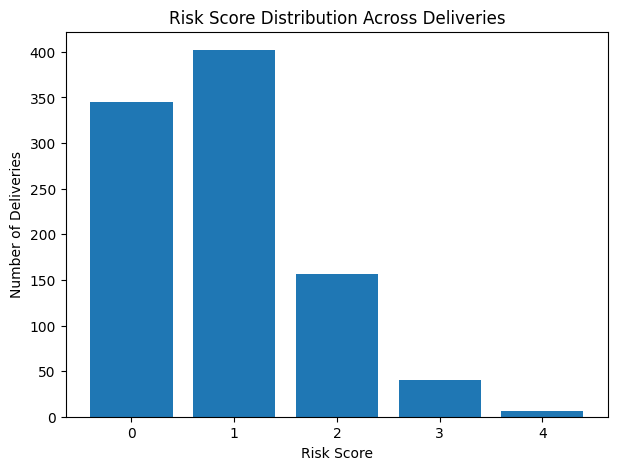

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(risk_distribution["Risk score"], risk_distribution["Deliveries"])
plt.xlabel("Risk Score")
plt.ylabel("Number of Deliveries")
plt.title("Risk Score Distribution Across Deliveries")
plt.xticks(risk_distribution["Risk score"])
plt.show()

In [ ]:
app_event_analysis = app_events.groupby("event_type").agg(
    Events=("event_id", "count"),
    Failures=("success_flag", lambda x: (x == 0).sum()),
    Avg_latency_ms=("api_latency_ms", "mean"),
    P90_latency_ms=("api_latency_ms", lambda x: x.quantile(0.90))
).reset_index()

app_event_analysis["Failure_rate_%"] = (
    app_event_analysis["Failures"] / app_event_analysis["Events"] * 100
)

app_event_analysis = app_event_analysis[
    ["event_type", "Events", "Failures", "Failure_rate_%", "Avg_latency_ms", "P90_latency_ms"]
].sort_values("Failure_rate_%", ascending=False)

app_event_analysis.round(2)

,event_type,Events,Failures,Failure_rate_%,Avg_latency_ms,P90_latency_ms
1,chat_escalated,38,19,50.00,478.13,986.8
5,payment_retry,69,19,27.54,472.68,755.0
2,chat_opened,88,0,0.00,478.33,787.4
0,cancel_attempt,28,0,0.00,417.14,646.9
3,delivery_instruction_update,75,0,0.00,496.29,847.2
4,eta_refresh,105,0,0.00,452.15,752.2
6,search_route,99,0,0.00,456.51,725.2
7,track_order,138,0,0.00,460.71,795.8


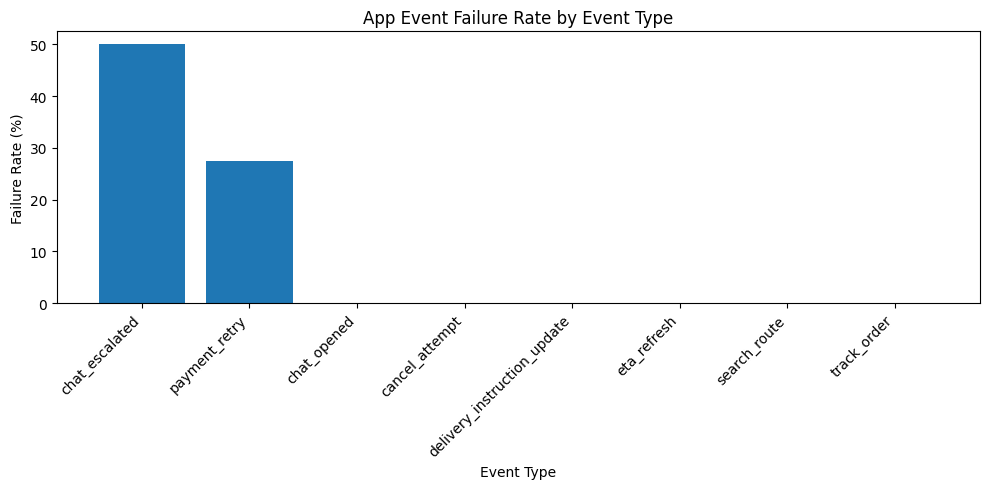

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(app_event_analysis["event_type"], app_event_analysis["Failure_rate_%"])
plt.xlabel("Event Type")
plt.ylabel("Failure Rate (%)")
plt.title("App Event Failure Rate by Event Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
main["direct_contribution_proxy"] = (
    main["order_value"] -
    main["fuel_or_charge_cost"] -
    main["total_compensation"].fillna(0)
)

profit_service = main.groupby("service_type").agg(
    deliveries=("delivery_id", "count"),
    avg_order_value=("order_value", "mean"),
    avg_cost=("fuel_or_charge_cost", "mean"),
    avg_contribution_proxy=("direct_contribution_proxy", "mean"),
    failure_rate=("is_failed", "mean"),
    complaint_rate=("has_complaint", "mean")
).reset_index()

profit_service["failure_rate_%"] = profit_service["failure_rate"] * 100
profit_service["complaint_rate_%"] = profit_service["complaint_rate"] * 100

profit_service = profit_service[
    [
        "service_type",
        "deliveries",
        "avg_order_value",
        "avg_cost",
        "avg_contribution_proxy",
        "failure_rate_%",
        "complaint_rate_%"
    ]
].sort_values("avg_contribution_proxy", ascending=False)

profit_service.round(2)

,service_type,deliveries,avg_order_value,avg_cost,avg_contribution_proxy,failure_rate_%,complaint_rate_%
3,Passenger,262,97.19,12.40,80.00,14.50,22.52
0,Business,126,97.45,13.14,78.38,19.84,22.22
2,Parcel,230,90.15,13.08,72.87,10.87,21.30
1,Medical,108,86.53,12.77,69.55,14.81,19.44
4,Retail,224,86.81,12.97,69.28,12.50,23.21


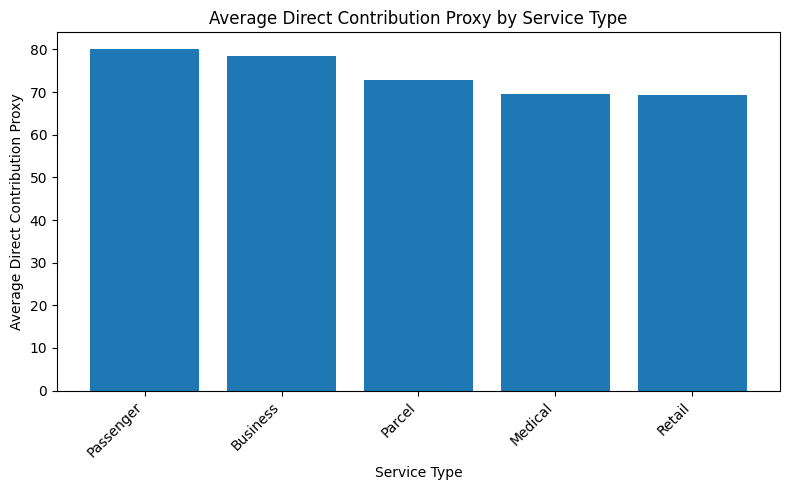

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(profit_service["service_type"], profit_service["avg_contribution_proxy"])
plt.xlabel("Service Type")
plt.ylabel("Average Direct Contribution Proxy")
plt.title("Average Direct Contribution Proxy by Service Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
zone_service_risk = main.groupby(["pickup_zone_clean", "service_type"]).agg(
    deliveries=("delivery_id", "count"),
    failed=("is_failed", "sum"),
    delay_rate=("is_delayed", "mean"),
    complaint_rate=("has_complaint", "mean"),
    avg_contribution_proxy=("direct_contribution_proxy", "mean")
).reset_index()

zone_service_risk["failure_rate_%"] = (
    zone_service_risk["failed"] / zone_service_risk["deliveries"] * 100
)

zone_service_risk["delay_rate_%"] = zone_service_risk["delay_rate"] * 100
zone_service_risk["complaint_rate_%"] = zone_service_risk["complaint_rate"] * 100

high_risk_zone_service = zone_service_risk[
    zone_service_risk["deliveries"] >= 15
].sort_values("failure_rate_%", ascending=False)

high_risk_zone_service = high_risk_zone_service[
    [
        "pickup_zone_clean",
        "service_type",
        "deliveries",
        "failed",
        "failure_rate_%",
        "delay_rate_%",
        "complaint_rate_%",
        "avg_contribution_proxy"
    ]
].head(10)

high_risk_zone_service.round(2)

,pickup_zone_clean,service_type,deliveries,failed,failure_rate_%,delay_rate_%,complaint_rate_%,avg_contribution_proxy
16,North,Medical,18,6,33.33,16.67,33.33,50.90
9,Central,Retail,49,13,26.53,28.57,20.41,62.87
5,Central,Business,24,6,25.00,29.17,20.83,100.85
20,Riverside,Business,17,4,23.53,11.76,35.29,86.02
15,North,Business,23,5,21.74,17.39,34.78,81.38
25,South,Business,19,4,21.05,31.58,10.53,67.22
33,West,Passenger,32,6,18.75,21.88,25.00,87.74
22,Riverside,Parcel,28,5,17.86,21.43,25.00,55.80
13,East,Passenger,45,8,17.78,20.00,28.89,94.83
19,North,Retail,32,5,15.62,25.00,25.00,83.19
